### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:

data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [6]:
# Drop the 'car' column
data = data.drop(columns=['car'])

4. What proportion of the total observations chose to accept the coupon?



In [7]:
round(data['Y'].mean(),2)

np.float64(0.57)

5. Use a bar plot to visualize the `coupon` column.

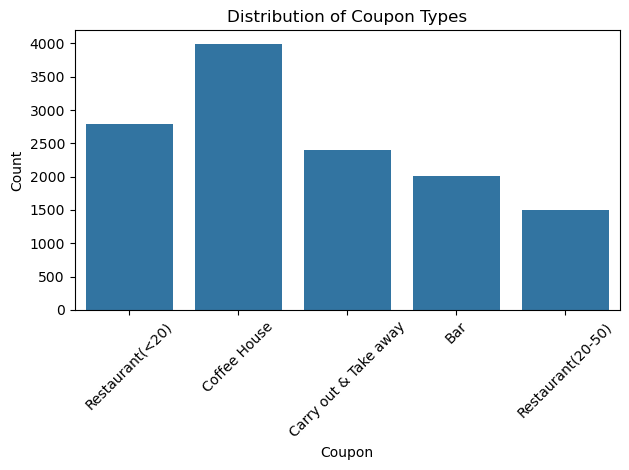

In [8]:
sns.countplot(data=data, x='coupon')
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()


6. Use a histogram to visualize the temperature column.

Text(0, 0.5, 'Count')

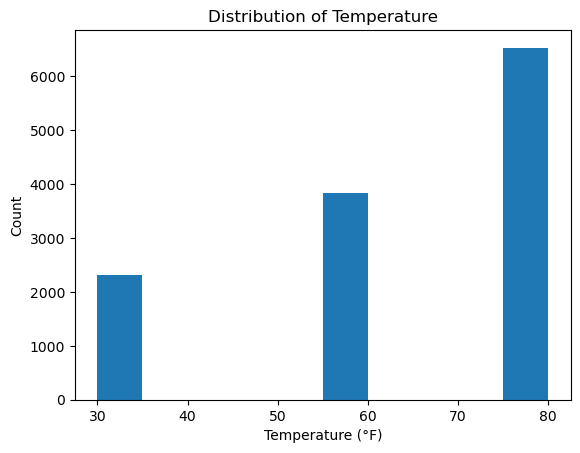

In [9]:
plt.hist(data['temperature'])
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [10]:
bar_coupons = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [11]:
bar_coupons_accepted = round(bar_coupons['Y'].mean(),2)
bar_coupons_accepted

np.float64(0.41)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [21]:
# Group 1: 3 or fewer bar visits per month
bar_low_freq = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])]
bar_low_freq_rate = bar_low_freq['Y'].mean()

# Group 2: More than 3 bar visits per month
bar_high_freq = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]
bar_high_freq_rate = bar_high_freq['Y'].mean()

print(f"≤3 visits/month acceptance rate: {bar_low_freq_rate:.1%}")
print(f">3 visits/month acceptance rate: {bar_high_freq_rate:.1%}")


≤3 visits/month acceptance rate: 37.1%
>3 visits/month acceptance rate: 76.9%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [22]:
# Target group: >1 bar visit/month AND age >25
bar_age_target = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (~bar_coupons['age'].isin(['below21', '21', '25']))
]
bar_age_target_rate = bar_age_target['Y'].mean()

# All others
bar_age_others = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
        (~bar_coupons['age'].isin(['below21', '21', '25']))
    )
]
bar_age_others_rate = bar_age_others['Y'].mean()

print(f">1 bar visit/month AND age >25: {bar_age_target_rate:.1%}")
print(f"All others: {bar_age_others_rate:.1%}")

>1 bar visit/month AND age >25: 69.5%
All others: 33.5%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [23]:
# Target group: >1 bar visit/month AND passenger is friend/partner AND not farming occupation
bar_pass_occ_target = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'].isin(['Friend(s)', 'Partner'])) &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]
bar_pass_occ_target_rate = bar_pass_occ_target['Y'].mean()

# All others
bar_pass_occ_others = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['passanger'].isin(['Friend(s)', 'Partner'])) &
        (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
    )
]
bar_pass_occ_others_rate = bar_pass_occ_others['Y'].mean()

print(f">1 bar visit, friend/partner, not farming: {bar_pass_occ_target_rate:.1%}")
print(f"All others: {bar_pass_occ_others_rate:.1%}")

>1 bar visit, friend/partner, not farming: 71.8%
All others: 37.7%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [26]:
# Group 1: >1 bar/month, no kids, not widowed
bar_nokid_notwidow = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
]
bar_nokid_notwidow_rate = bar_nokid_notwidow['Y'].mean()

# Group 2: >1 bar/month, age <30
bar_under30 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['below21', '21', '26']))
]
bar_under30_rate = bar_under30['Y'].mean()

# Group 3: >4 cheap restaurant visits, income <50K
bar_cheaprest_lowinc = bar_coupons[
    (bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupons['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))
]
bar_cheaprest_lowinc_rate = bar_cheaprest_lowinc['Y'].mean()

print(f">1 bar, no kids, not widowed: {bar_nokid_notwidow_rate:.1%}")
print(f">1 bar, age <30: {bar_under30_rate:.1%}")
print(f">4 cheap restaurants, income <50K: {bar_cheaprest_lowinc_rate:.1%}")

>1 bar, no kids, not widowed: 71.3%
>1 bar, age <30: 72.2%
>4 cheap restaurants, income <50K: 45.3%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

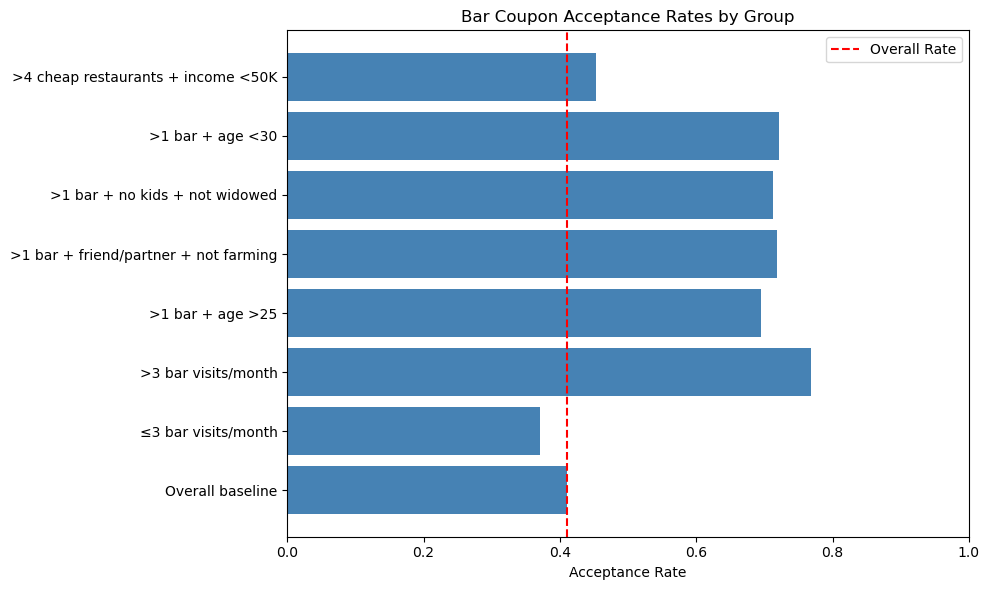

In [28]:
groups = [
    'Overall baseline',
    '≤3 bar visits/month',
    '>3 bar visits/month',
    '>1 bar + age >25',
    '>1 bar + friend/partner + not farming',
    '>1 bar + no kids + not widowed',
    '>1 bar + age <30',
    '>4 cheap restaurants + income <50K'
]
rates = [
    bar_coupons['Y'].mean(),
    bar_low_freq_rate,
    bar_high_freq_rate,
    bar_age_target_rate,
    bar_pass_occ_target_rate,
    bar_nokid_notwidow_rate,
    bar_under30_rate,
    bar_cheaprest_lowinc_rate
]

plt.figure(figsize=(10, 6))
plt.barh(groups, rates, color='steelblue')
plt.xlabel('Acceptance Rate')
plt.title('Bar Coupon Acceptance Rates by Group')
plt.xlim(0, 1)
plt.axvline(x=bar_coupons['Y'].mean(), color='red', linestyle='--', label='Overall Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Hypothesis: Bar Coupon Acceptance

Drivers who accept bar coupons are primarily **frequent bar-goers** (>1 visit/month). This single factor nearly doubles acceptance rates from ~37% to ~70%+. 

Additional factors (age, passengers, marital status) have minimal incremental effect once bar-going frequency is accounted for. 

The cheap restaurant/low income group (~45%) shows that general dining-out behavior doesn't transfer to bar coupon acceptance — it's specifically about existing bar-going habits.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

## Independent Investigation: Coffee House Coupons

### Data Preparation

In [29]:
# Filter to Coffee House coupons only
coffee_coupons = data[data['coupon'] == 'Coffee House']

# Baseline acceptance rate
coffee_acceptance_rate = coffee_coupons['Y'].mean()

print(f"Coffee House coupons: {len(coffee_coupons)} observations")
print(f"Acceptance rate: {coffee_acceptance_rate:.1%}")

Coffee House coupons: 3996 observations
Acceptance rate: 49.9%


### Exploring Coffee House Visit Frequency


In [30]:
# Distribution of coffee house visit frequency
coffee_coupons['CoffeeHouse'].value_counts()

CoffeeHouse
less1    1075
1~3      1042
never     927
4~8       538
gt8       342
Name: count, dtype: int64

### Acceptance Rate by Coffee House Visit Frequency


In [31]:
# Infrequent visitors: 3 or fewer times per month
coffee_low_freq = coffee_coupons[coffee_coupons['CoffeeHouse'].isin(['never', 'less1', '1~3'])]
coffee_low_freq_rate = coffee_low_freq['Y'].mean()

# Frequent visitors: more than 3 times per month
coffee_high_freq = coffee_coupons[coffee_coupons['CoffeeHouse'].isin(['4~8', 'gt8'])]
coffee_high_freq_rate = coffee_high_freq['Y'].mean()

print(f"≤3 visits/month acceptance rate: {coffee_low_freq_rate:.1%}")
print(f">3 visits/month acceptance rate: {coffee_high_freq_rate:.1%}")

≤3 visits/month acceptance rate: 44.9%
>3 visits/month acceptance rate: 67.5%


### Acceptance Rate by Time of Day


In [32]:
# Check time values
coffee_coupons['time'].value_counts()

time
6PM     1093
7AM      913
10AM     899
2PM      794
10PM     297
Name: count, dtype: int64

In [33]:
# Acceptance rate by time of day
coffee_by_time = coffee_coupons.groupby('time')['Y'].mean().sort_values(ascending=False)
print(coffee_by_time)

time
10AM    0.640712
2PM     0.547859
7AM     0.445783
10PM    0.424242
6PM     0.412626
Name: Y, dtype: float64


### Visualization: Acceptance Rate by Time of Day

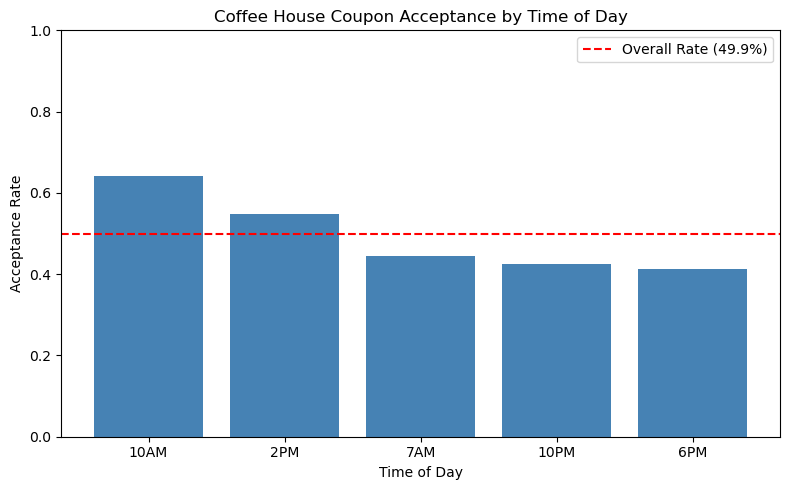

In [34]:
coffee_by_time = coffee_coupons.groupby('time')['Y'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(coffee_by_time.index, coffee_by_time.values, color='steelblue')
plt.xlabel('Time of Day')
plt.ylabel('Acceptance Rate')
plt.title('Coffee House Coupon Acceptance by Time of Day')
plt.ylim(0, 1)
plt.axhline(y=coffee_acceptance_rate, color='red', linestyle='--', label='Overall Rate (49.9%)')
plt.legend()
plt.tight_layout()
plt.show()

### Acceptance Rate by Temperature

In [35]:
# Acceptance rate by temperature
coffee_by_temp = coffee_coupons.groupby('temperature')['Y'].mean().sort_values(ascending=False)
print(coffee_by_temp)

temperature
80    0.529779
55    0.455756
30    0.443396
Name: Y, dtype: float64


### Acceptance Rate by Passenger Type

In [36]:
# Acceptance rate by passenger type
coffee_by_passenger = coffee_coupons.groupby('passanger')['Y'].mean().sort_values(ascending=False)
print(coffee_by_passenger)

passanger
Friend(s)    0.596906
Partner      0.570492
Kid(s)       0.483092
Alone        0.437943
Name: Y, dtype: float64


### Acceptance Rate by Destination

In [37]:
# Acceptance rate by destination
coffee_by_dest = coffee_coupons.groupby('destination')['Y'].mean().sort_values(ascending=False)
print(coffee_by_dest)

destination
No Urgent Place    0.580974
Work               0.445783
Home               0.362069
Name: Y, dtype: float64


### Summary: Coffee House Coupon Acceptance Rates by Factor

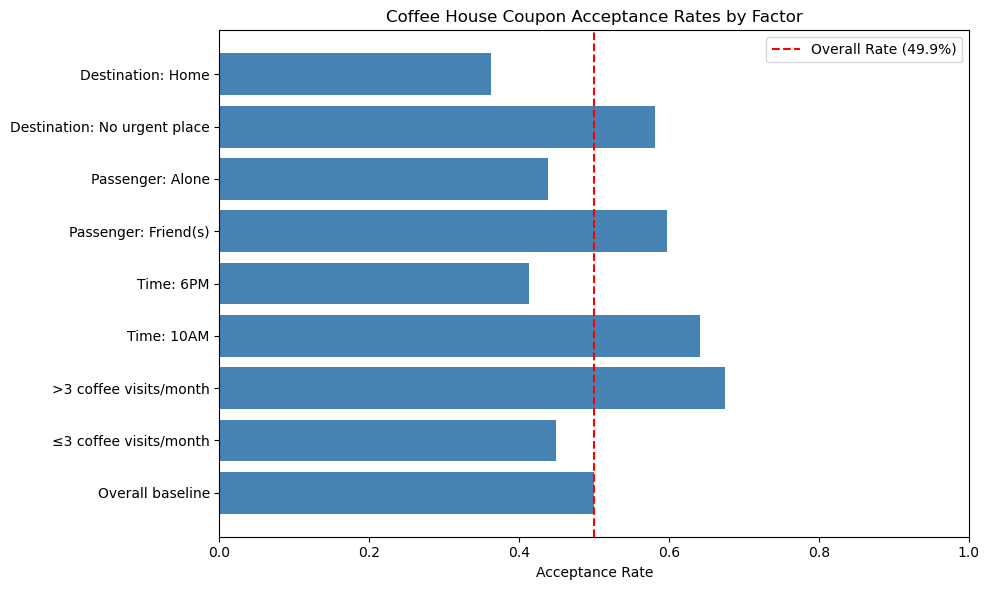

In [38]:
groups = [
    'Overall baseline',
    '≤3 coffee visits/month',
    '>3 coffee visits/month',
    'Time: 10AM',
    'Time: 6PM',
    'Passenger: Friend(s)',
    'Passenger: Alone',
    'Destination: No urgent place',
    'Destination: Home'
]
rates = [
    coffee_acceptance_rate,
    coffee_low_freq_rate,
    coffee_high_freq_rate,
    coffee_by_time['10AM'],
    coffee_by_time['6PM'],
    coffee_by_passenger['Friend(s)'],
    coffee_by_passenger['Alone'],
    coffee_by_dest['No Urgent Place'],
    coffee_by_dest['Home']
]

plt.figure(figsize=(10, 6))
plt.barh(groups, rates, color='steelblue')
plt.xlabel('Acceptance Rate')
plt.title('Coffee House Coupon Acceptance Rates by Factor')
plt.xlim(0, 1)
plt.axvline(x=coffee_acceptance_rate, color='red', linestyle='--', label='Overall Rate (49.9%)')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion: Coffee House Coupon Acceptance

### Key Findings

**Visit frequency is the strongest predictor** — drivers who visit coffee houses more than 3 times per month accept at 67.5% vs. 44.9% for less frequent visitors. This mirrors the bar coupon pattern, though the gap is smaller.

**Context matters significantly:**
- **Time of day:** 10AM is the peak acceptance time (64%), likely representing the mid-morning coffee break. Early morning (7AM) and evening times underperform.
- **Social context:** Drivers with friends (60%) or partners (57%) accept more than those alone (44%). Coffee is a social activity.
- **Destination flexibility:** Drivers with no urgent destination accept at 58%, while those heading home accept only 36%.

### Comparison to Bar Coupons

| Factor | Bar Coupons | Coffee House |
|--------|-------------|--------------|
| Baseline acceptance | 41% | 50% |
| High frequency boost | +40 pts (37%→77%) | +23 pts (45%→68%) |
| Kids as passengers | Strong negative | Neutral |
| Social context | Moderate effect | Strong effect |

### Recommendations

1. **Target frequent coffee house visitors** — they accept at 68%
2. **Deliver coupons around 10AM** — peak acceptance window
3. **Target drivers with passengers** — social context boosts acceptance
4. **Avoid targeting drivers heading home** — lowest acceptance rate

### Next Steps

1. **Build a predictive model** — Use these features to predict coupon acceptance
2. **Explore interaction effects** — Do combinations of factors compound acceptance rates?
3. **Analyze remaining coupon types** — Apply this framework to Restaurant and Carry Out coupons